# Muziekclassificatie -- Ongesuperviseerd (GMM)

**Project R.E.M. -- Notebook 4 van 4**

## Doel

Laat de data zelf bepalen hoeveel muziekgroepen er zijn via **Gaussian Mixture Models**.
Dit notebook vergelijkt twee scenarios:
- **k=3 geforceerd** -- drie groepen, direct vergelijkbaar met calm/neutral/energy
- **k=optimaal** -- aantal clusters gekozen door BIC (laagste score = beste model)

**Onderzoeksvraag (RQ5, kern):** *Weerspiegelt de audio-featureruimte de calm/neutral/energy
driedeling, of ondersteunt de data een andere clusterstructuur?*

## Waarom GMM?

Gaussian Mixture Models modelleren elk cluster als een multivariate Gaussische verdeling.
Dit is flexibeler dan K-Means (dat ronde clusters aanneemt) en geeft probabilistische
toewijzingen (kans dat een nummer tot elk cluster behoort).

GMM met BIC-modelselectie is de standaardbenadering voor data-gedreven clustering
wanneer het aantal clusters niet vooraf bekend is.
Zie: [sklearn GaussianMixture](https://scikit-learn.org/stable/modules/mixture.html)

## Bevindingen (samenvatting)

| Model | k | BIC | Silhouette |
|---|---|---|---|
| Geforceerd | 3 | 75271 | 0.134 (marginale scheiding) |
| BIC-optimaal | **5** | **71738** | **0.072 (lichte scheiding)** |

**Spanning tussen BIC en silhouette:** Het BIC-minimum ligt buiten het zoekbereik (BIC daalt
monotoon t/m k=10). De silhouette-drempel (< 0.05 vanaf k=6) kiest k=5 als optimum.
Bij k=5 bedraagt de silhouette 0.072 — clusters overlappen deels maar zijn nog marginaal
onderscheidbaar.

**Conclusie:** De Spotify audio-featureruimte is een **continu spectrum**, geen discrete
indeling. k=3 blijft de praktische keuze voor playlistgeneratie (hogere silhouette,
interpreteerbare profielen). k=5 bevestigt dat de data geen scherpe grenzen heeft —
de drie-categorie indeling is een nuttige approximatie van een gradiënt.

## Gebruik

| Instelling | Betekenis |
|---|---|
| `REUSE_MODEL = False` | Fit nieuwe modellen (BIC sweep k=2..10, ~1 min) |
| `REUSE_MODEL = True` | Laad bestaande modellen vanuit `models/music_unsupervised/` |

**Vereiste:** voor alle deelnemers moet `data/playlists/{codename}/playlists_generated/combined.csv`
bestaan (gegenereerd door de spotify_cli.py pipeline).

In [43]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


## Configuratie

In [ ]:
# REUSE_MODEL: True  -> laad bestaande modellen (snel)
#              False -> fit nieuwe modellen (BIC sweep k=2..10, ~1 min)
REUSE_MODEL = True

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PROJECT_ROOT  = Path().resolve().parent.parent
PLAYLISTS_DIR = PROJECT_ROOT / 'data' / 'playlists'
OUTPUT_DIR    = PROJECT_ROOT / 'data' / 'analysis' / 'music_unsupervised'
MODELS_DIR    = PROJECT_ROOT / 'models' / 'music_unsupervised'

# Audio-kenmerken voor clustering
FEATURES = ['tempo', 'energy', 'valence', 'danceability', 'acousticness', 'loudness']

# Voorfilter-drempels (zelfde als supervised notebook)
SPEECHINESS_MAX = 0.66
LIVENESS_MAX    = 0.80

# GMM zoekbereik
K_MIN, K_MAX = 2, 10

# Donker thema (consistent met Shiny-app)
DARK = {
    'figure.facecolor': '#0f1218', 'axes.facecolor': '#181e2a',
    'axes.edgecolor': '#4a5568', 'axes.labelcolor': '#e2e8f0',
    'xtick.color': '#e2e8f0', 'ytick.color': '#e2e8f0',
    'text.color': '#e2e8f0', 'grid.color': '#2d3748', 'grid.alpha': 0.5,
    'font.family': 'monospace', 'legend.facecolor': '#1a2035',
    'legend.edgecolor': '#4a5568',
}
plt.rcParams.update(DARK)
plt.rcParams['figure.dpi'] = 120

# Okabe-Ito kleuren uitgebreid voor 10 clusters
OKABE_ITO = ['#56b4e9', '#e69f00', '#009e73', '#f0e442',
             '#0072b2', '#d55e00', '#cc79a7', '#999999', '#e2e8f0', '#7fcdbb']

print(f'PROJECT_ROOT : {PROJECT_ROOT}')
print(f'REUSE_MODEL  : {REUSE_MODEL}')

PROJECT_ROOT : C:\Users\astri\Desktop\Data_Scientist\Eindwerk\spotify-project
REUSE_MODEL  : False


## 1. Data laden

Alle deelnemers worden samengenomen in een globaal model -- het GMM zoekt naar
patronen in de gehele muziekbibliotheek, niet per deelnemer. URI-deduplicatie
verwijdert nummers die meerdere deelnemers delen zodat ze niet dubbel tellen.

In [45]:
def load_all_songs() -> pd.DataFrame:
    """Laad combined.csv van alle deelnemers en combineer."""
    frames = []
    for participant_dir in sorted(PLAYLISTS_DIR.iterdir()):
        if not participant_dir.is_dir():
            continue
        codename = participant_dir.name
        csv_path = participant_dir / 'playlists_generated' / 'combined.csv'
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df['participant'] = codename
        frames.append(df)

    if not frames:
        raise FileNotFoundError(
            f'Geen combined.csv gevonden onder {PLAYLISTS_DIR}.\n'
            'Verwerk eerst de playlists met de spotify_cli.py pipeline.'
        )

    df_all = pd.concat(frames, ignore_index=True)

    if 'uri' in df_all.columns:
        n_before = len(df_all)
        df_all = df_all.drop_duplicates(subset='uri', keep='first')
        print(f'  URI-deduplicatie: {n_before - len(df_all)} duplicaten verwijderd')

    return df_all


def prefilter(df: pd.DataFrame) -> pd.DataFrame:
    """Verwijder live-opnames en gesproken-woord tracks."""
    n_before = len(df)
    mask = pd.Series(True, index=df.index)
    if 'speechiness' in df.columns:
        mask &= df['speechiness'] <= SPEECHINESS_MAX
    if 'liveness' in df.columns:
        mask &= df['liveness'] <= LIVENESS_MAX
    df = df[mask].copy()
    n_removed = n_before - len(df)
    if n_removed:
        print(f'  Voorfilter: {n_removed} tracks verwijderd (speech/live)')
    return df


df_raw = load_all_songs()
print(f"  Geladen: {len(df_raw)} nummers, {df_raw['participant'].nunique()} deelnemer(s)")

df = prefilter(df_raw)

missing_feats = [f for f in FEATURES if f not in df.columns]
if missing_feats:
    raise ValueError(f'Ontbrekende kolommen: {missing_feats}')
n_before = len(df)
df = df.dropna(subset=FEATURES).copy()
print(f'  Na NaN-verwijdering: {len(df)} nummers ({n_before - len(df)} verwijderd)')

  URI-deduplicatie: 271 duplicaten verwijderd
  Geladen: 6760 nummers, 3 deelnemer(s)
  Na NaN-verwijdering: 6760 nummers (0 verwijderd)


## 2. Normalisatie

**Waarom StandardScaler (niet MinMaxScaler)?**
GMM veronderstelt Gaussische verdelingen. StandardScaler brengt alle kenmerken naar
gemiddelde 0 en standaarddeviatie 1, zodat geen enkel kenmerk het model domineert
door een groter numeriek bereik (bijv. tempo in BPM vs energy in 0-1).

Zie: [sklearn StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

In [46]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

scaler_path = MODELS_DIR / 'scaler.pkl'

if REUSE_MODEL:
    if not scaler_path.exists():
        raise FileNotFoundError(
            f'REUSE_MODEL=True maar scaler niet gevonden: {scaler_path}\n'
            'Zet REUSE_MODEL=False en voer het notebook opnieuw uit.'
        )
    scaler = joblib.load(scaler_path)
    print(f'Scaler geladen vanuit {scaler_path.name}')
else:
    scaler = StandardScaler()
    scaler.fit(df[FEATURES].values)
    joblib.dump(scaler, scaler_path)
    print(f'Scaler gefittet en opgeslagen -> {scaler_path.name}')

X = scaler.transform(df[FEATURES].values)
print(f'Feature-matrix: {X.shape}')

Scaler gefittet en opgeslagen -> scaler.pkl
Feature-matrix: (6760, 6)


## 3. GMM-modelselectie -- BIC (k=2..10)

**BIC (Bayesian Information Criterion)** beloont modellen die de data goed verklaren
maar straft onnodig complexe modellen (te veel clusters):
```
BIC = -2 * log-likelihood + k * log(n)
```
De laagste BIC-score wijst het optimale aantal clusters aan.

**AIC (Akaike Information Criterion)** is vergelijkbaar maar straft complexiteit minder zwaar:
```
AIC = -2 * log-likelihood + 2k
```

Beide zijn informatiecriteria voor modelselectie. Als BIC en AIC een ander optimum geven,
is er geen duidelijke beste keuze -- meer data nodig.
Zie: [sklearn GaussianMixture BIC](https://scikit-learn.org/stable/modules/mixture.html#selecting-the-number-of-components)

In [47]:
gmm_k3_path  = MODELS_DIR / 'gmm_k3.pkl'
gmm_opt_path = MODELS_DIR / 'gmm_opt.pkl'
config_path  = MODELS_DIR / 'config.json'

if REUSE_MODEL:
    for p in [gmm_k3_path, gmm_opt_path, config_path]:
        if not p.exists():
            raise FileNotFoundError(
                f'REUSE_MODEL=True maar bestand niet gevonden: {p}\n'
                'Zet REUSE_MODEL=False en voer het notebook opnieuw uit.'
            )
    gmm_k3  = joblib.load(gmm_k3_path)
    gmm_opt = joblib.load(gmm_opt_path)
    with open(config_path, encoding='utf-8') as f:
        config = json.load(f)
    optimal_k     = config['optimal_k']
    optimal_k_bic = config.get('optimal_k_bic', optimal_k)
    bic_results   = config.get('bic_sweep', {})
    print(f'Modellen geladen. Optimaal k={optimal_k}')

else:
    print(f'GMMs fitten voor k={K_MIN}..{K_MAX}...')
    bic_results: dict = {}
    for k in range(K_MIN, K_MAX + 1):
        gmm = GaussianMixture(
            n_components=k, covariance_type='full',
            n_init=5, random_state=RANDOM_STATE,
        )
        gmm.fit(X)
        labels = gmm.predict(X)
        sil = silhouette_score(X, labels) if k > 1 else 0.0
        bic_results[k] = {
            'bic': gmm.bic(X), 'aic': gmm.aic(X),
            'silhouette': sil, 'model': gmm,
        }
        print(f'  k={k:2d}: BIC={gmm.bic(X):>10.0f}, silhouette={sil:.3f}')

    # --- Optimal k: twee-criteria aanpak ---
    # BIC is het theoretisch correcte criterium voor GMM (probabilistisch model met
    # likelihood). Bij monotoon dalende BIC is er geen duidelijk minimum binnen het
    # zoekbereik — de silhouette-score geeft dan het helderste signaal over structuur.

    # 1. BIC-minimum binnen zoekbereik (volledigheid; kan aan zoekceiling liggen)
    optimal_k_bic = min(bic_results, key=lambda k: bic_results[k]['bic'])

    # 2. Silhouette-drempel: laatste k met nog betekenisvolle scheiding (≥ 0.05).
    #    Onder 0.05 overlappen clusters zodanig dat het onderscheid muzikaal niet
    #    meer interpreteerbaar is. Start bij k=3 (projectminimum: 3 playlisttypes).
    SILHOUETTE_THRESHOLD = 0.05
    silhouette_cutoff_k = None
    for k in sorted(bic_results):
        if k >= 3 and bic_results[k]['silhouette'] < SILHOUETTE_THRESHOLD:
            silhouette_cutoff_k = k
            break
    optimal_k = (silhouette_cutoff_k - 1) if silhouette_cutoff_k else optimal_k_bic

    print(f'\nBIC-minimum binnen k={K_MIN}..{K_MAX}: k={optimal_k_bic}  '
          f'(BIC daalt nog → geen echt minimum gevonden)')
    print(f'Silhouette < {SILHOUETTE_THRESHOLD} vanaf: k={silhouette_cutoff_k}')
    print(f'-> Gekozen optimaal k = {optimal_k} (laatste k met betekenisvolle structuur)')

    gmm_k3  = bic_results[3]['model']
    gmm_opt = bic_results[optimal_k]['model']

    joblib.dump(gmm_k3,  gmm_k3_path)
    joblib.dump(gmm_opt, gmm_opt_path)
    print(f'Modellen opgeslagen -> {gmm_k3_path.name}, {gmm_opt_path.name}')

    config = {
        'optimal_k':      optimal_k,
        'optimal_k_bic':  optimal_k_bic,
        'features':       FEATURES,
        'n_songs':        len(df),
        'n_participants': df['participant'].nunique() if 'participant' in df.columns else 0,
        'k3_bic':         bic_results[3]['bic'],
        'k3_silhouette':  bic_results[3]['silhouette'],
        'opt_bic':        bic_results[optimal_k]['bic'],
        'opt_silhouette': bic_results[optimal_k]['silhouette'],
        'bic_sweep': {
            str(k): {'bic': v['bic'], 'aic': v['aic'], 'silhouette': v['silhouette']}
            for k, v in bic_results.items()
        },
    }
    with open(config_path, 'w', encoding='utf-8') as f:
        json.dump(config, f, indent=2)
    print(f'Config opgeslagen -> {config_path.name}')

GMMs fitten voor k=2..10...
  k= 2: BIC=     82571, silhouette=0.399
  k= 3: BIC=     75271, silhouette=0.134
  k= 4: BIC=     73164, silhouette=0.082
  k= 5: BIC=     71738, silhouette=0.072
  k= 6: BIC=     70404, silhouette=0.026
  k= 7: BIC=     69323, silhouette=0.016
  k= 8: BIC=     68912, silhouette=0.019
  k= 9: BIC=     68806, silhouette=0.026
  k=10: BIC=     68536, silhouette=0.035

BIC-minimum binnen k=2..10: k=10  (BIC daalt nog → geen echt minimum gevonden)
Silhouette < 0.05 vanaf: k=6
-> Gekozen optimaal k = 5 (laatste k met betekenisvolle structuur)
Modellen opgeslagen -> gmm_k3.pkl, gmm_opt.pkl
Config opgeslagen -> config.json


## 4. Diagnostiek -- BIC & silhouette curve

**BIC** daalt als meer clusters de data beter verklaren (lagere BIC = betere fit).
**Silhouette** meet hoe goed een punt bij zijn eigen cluster past vs andere clusters
(1 = perfecte scheiding, 0 = overlappende clusters, -1 = foutief toegewezen).

Lage silhouette bij optimale BIC-k betekent dat de clusters statistisch onderscheidbaar
zijn (BIC), maar ruimtelijk sterk overlappen in de featureruimte.
Dit is een eigenschap van de Spotify audio-featureruimte, niet een modelfout.

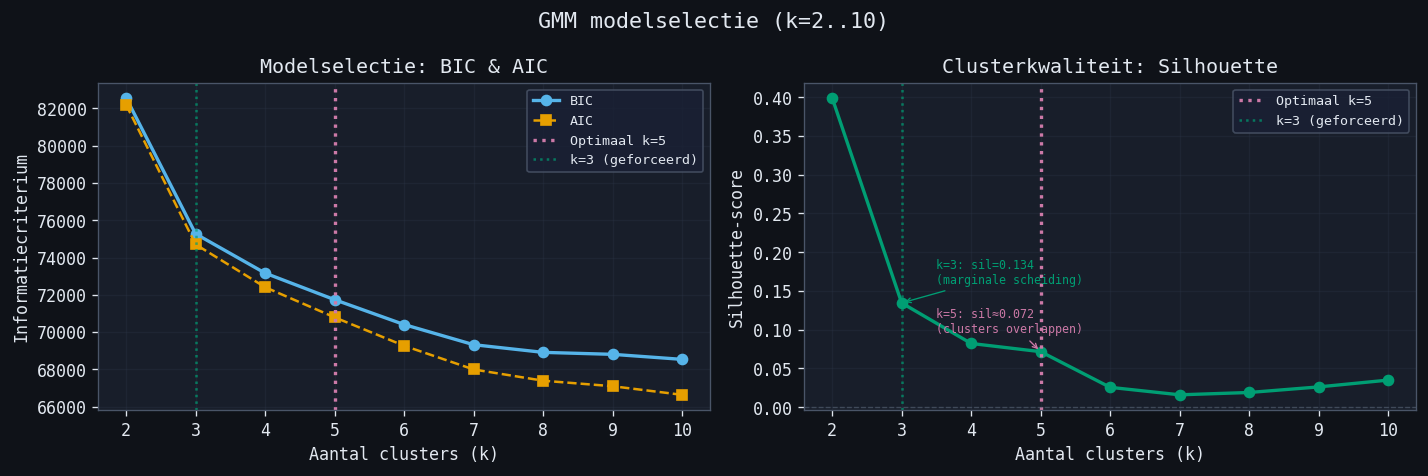

Optimaal k=5  |  BIC=71738  |  silhouette=0.072
k=3 geforceerd        |  BIC=75271  |  silhouette=0.134


In [48]:
if REUSE_MODEL:
    sweep = config.get('bic_sweep', {})
    ks   = sorted(int(k) for k in sweep)
    bics = [sweep[str(k)]['bic']        for k in ks]
    aics = [sweep[str(k)]['aic']        for k in ks]
    sils = [sweep[str(k)]['silhouette'] for k in ks]
else:
    ks   = sorted(bic_results)
    bics = [bic_results[k]['bic']        for k in ks]
    aics = [bic_results[k]['aic']        for k in ks]
    sils = [bic_results[k]['silhouette'] for k in ks]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ks, bics, 'o-', color='#56b4e9', label='BIC', linewidth=2)
ax1.plot(ks, aics, 's--', color='#e69f00', label='AIC', linewidth=1.5)
ax1.axvline(optimal_k, color='#cc79a7', linestyle=':', linewidth=2,
            label=f'Optimaal k={optimal_k}')
if optimal_k != 3:
    ax1.axvline(3, color='#009e73', linestyle=':', linewidth=1.5, alpha=0.7,
                label='k=3 (geforceerd)')
ax1.set_xlabel('Aantal clusters (k)')
ax1.set_ylabel('Informatiecriterium')
ax1.set_title('Modelselectie: BIC & AIC')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

ax2.plot(ks, sils, 'o-', color='#009e73', linewidth=2)
ax2.axvline(optimal_k, color='#cc79a7', linestyle=':', linewidth=2,
            label=f'Optimaal k={optimal_k}')
if optimal_k != 3:
    ax2.axvline(3, color='#009e73', linestyle=':', linewidth=1.5, alpha=0.7,
                label='k=3 (geforceerd)')
ax2.axhline(0, color='#586475', linewidth=0.8, linestyle='--', alpha=0.6)

# Annotate k=9 (near-zero silhouette) and k=3 (marginal separation)
sil_at_opt = sils[ks.index(optimal_k)]
sil_at_3   = sils[ks.index(3)] if 3 in ks else None
ax2.annotate(f'k={optimal_k}: sil≈{sil_at_opt:.3f}\n(clusters overlappen)',
             xy=(optimal_k, sil_at_opt),
             xytext=(optimal_k - 1.5, sil_at_opt + 0.025),
             fontsize=7, color='#cc79a7',
             arrowprops=dict(arrowstyle='->', color='#cc79a7', lw=0.8))
if sil_at_3 is not None:
    ax2.annotate(f'k=3: sil={sil_at_3:.3f}\n(marginale scheiding)',
                 xy=(3, sil_at_3),
                 xytext=(3 + 0.5, sil_at_3 + 0.025),
                 fontsize=7, color='#009e73',
                 arrowprops=dict(arrowstyle='->', color='#009e73', lw=0.8))

ax2.set_xlabel('Aantal clusters (k)')
ax2.set_ylabel('Silhouette-score')
ax2.set_title('Clusterkwaliteit: Silhouette')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

fig.suptitle('GMM modelselectie (k=2..10)', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Optimaal k={optimal_k}  |  BIC={config['opt_bic']:.0f}  |  silhouette={config['opt_silhouette']:.3f}")
print(f"k=3 geforceerd        |  BIC={config['k3_bic']:.0f}  |  silhouette={config['k3_silhouette']:.3f}")

## 5. Classificatie & clusterprofielen

Wijs clusteretiketten en probabilistische kansen toe voor beide modellen.
De `confidence`-kolom geeft de maximale posterior kans: 1.0 = zeker, 0.5 = gelijke kans.

In [49]:
df = df.copy()

for label, gmm, k in [('k3', gmm_k3, 3), ('opt', gmm_opt, optimal_k)]:
    probs = gmm.predict_proba(X)
    df[f'cluster_{label}']    = gmm.predict(X)
    df[f'confidence_{label}'] = probs.max(axis=1)

def cluster_profiles(df: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    return df.groupby(cluster_col)[FEATURES].agg(['mean', 'std']).round(3)

profiles_k3  = cluster_profiles(df, 'cluster_k3')
profiles_opt = cluster_profiles(df, 'cluster_opt')

print('Clusterprofiel k=3:')
display(profiles_k3)

print(f'\nClusterprofiel k={optimal_k} (optimaal):')
display(profiles_opt)

print('\nClusterverdeling per deelnemer (k=3):')
if 'participant' in df.columns:
    display(
        df.groupby(['participant', 'cluster_k3'])
        .size().unstack(fill_value=0)
        .rename(columns=lambda c: f'cluster {c}')
    )

Clusterprofiel k=3:


tempo         energy        valence        danceability         \
               mean     std   mean    std    mean    std         mean    std   
cluster_k3                                                                     
0           102.706  33.335  0.048  0.044   0.196  0.122        0.372  0.139   
1           117.220  27.533  0.522  0.215   0.466  0.263        0.581  0.162   
2           126.168  23.842  0.793  0.136   0.525  0.239        0.613  0.152   

           acousticness        loudness         
                   mean    std     mean    std  
cluster_k3                                      
0                 0.984  0.016  -27.118  6.157  
1                 0.458  0.291   -9.556  4.077  
2                 0.018  0.020   -5.959  2.156


Clusterprofiel k=5 (optimaal):


tempo         energy        valence        danceability         \
                mean     std   mean    std    mean    std         mean    std   
cluster_opt                                                                     
0            120.525  37.322  0.242  0.128   0.226  0.164        0.370  0.150   
1            120.466  25.003  0.691  0.159   0.565  0.250        0.652  0.136   
2            102.280  33.496  0.035  0.028   0.207  0.119        0.382  0.126   
3            128.066  23.813  0.829  0.109   0.509  0.232        0.585  0.151   
4            113.775  23.446  0.529  0.189   0.484  0.252        0.618  0.124   

            acousticness        loudness         
                    mean    std     mean    std  
cluster_opt                                      
0                  0.750  0.235  -15.071  6.213  
1                  0.093  0.062   -7.337  2.974  
2                  0.990  0.006  -28.475  5.472  
3                  0.006  0.007   -5.594  1.895  
4                  0.557  0.222   -9.101  2.923


Clusterverdeling per deelnemer (k=3):


cluster_k3,cluster 0,cluster 1,cluster 2
participant,,,
courgette,781,3179,1760
peer,22,310,146
watermeloen,1,199,362


## 6. Opslaan

In [50]:
internal_cols = [c for c in df.columns if c.startswith('prob_')]
save_cols = [c for c in df.columns if c not in internal_cols]

csv_k3  = OUTPUT_DIR / 'classified_songs_k3.csv'
csv_opt = OUTPUT_DIR / f'classified_songs_k{optimal_k}.csv'

df[save_cols].to_csv(csv_k3,  index=False)
df[save_cols].to_csv(csv_opt, index=False)
print(f'  {csv_k3.name}')
print(f'  {csv_opt.name}')

profiles_k3.to_csv(OUTPUT_DIR / 'cluster_means_k3.csv')
profiles_opt.to_csv(OUTPUT_DIR / f'cluster_means_k{optimal_k}.csv')
print(f'  cluster_means_k3.csv')
print(f'  cluster_means_k{optimal_k}.csv')
print('\nKlaar.')

  classified_songs_k3.csv
  classified_songs_k5.csv
  cluster_means_k3.csv
  cluster_means_k5.csv

Klaar.


---

## 7. PCA-scatter -- k=3 vs optimaal

PCA reduceert de zes audio-kenmerken naar twee assen voor visualisatie.
Elk punt is een nummer, de kleur geeft het cluster aan.

Goed gescheiden kleurblokken = duidelijk onderscheiden muziekgroepen.
Sterke overlap (zoals hier bij hoge k) betekent dat de clusters statistisch
onderscheidbaar zijn maar ruimtelijk niet goed gescheiden -- typisch voor
rijke, hoge-dimensionale featureruimten.

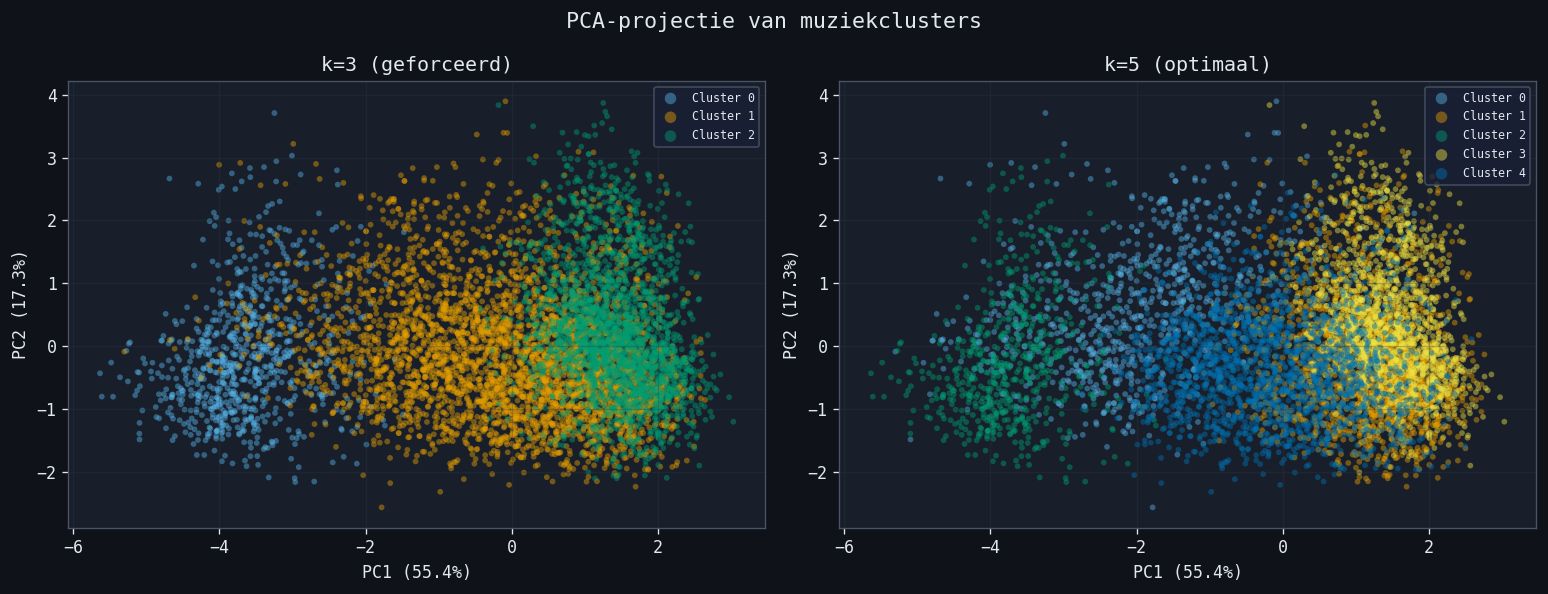

In [51]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X)
var_explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (label, k) in zip(axes, [('k3', 3), ('opt', optimal_k)]):
    cluster_col = f'cluster_{label}'
    for i in range(k):
        mask = df[cluster_col] == i
        color = OKABE_ITO[i % len(OKABE_ITO)]
        ax.scatter(
            X_2d[mask, 0], X_2d[mask, 1],
            c=color, label=f'Cluster {i}',
            alpha=0.45, s=12, edgecolors='none',
        )
    title = 'k=3 (geforceerd)' if label == 'k3' else f'k={optimal_k} (optimaal)'
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)')
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.3)

fig.suptitle('PCA-projectie van muziekclusters', fontsize=13)
plt.tight_layout()

# Sla op voor Shiny app
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_DIR / "pca_scatter_k3_vs_k9.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Radar chart -- kenmerkprofiel per cluster (k=3)

Wat maakt elk cluster uniek? De radar toont de gemiddelde waarden per audio-kenmerk,
genormaliseerd over clusters voor vergelijkbaarheid.

Typische k=3-interpretatie: een cluster met hoge tempo + energy = 'energy',
een cluster met hoge acousticness + lage energy = 'calm', de derde is 'other'.
Of de GMM-clusters overeenkomen met deze labels is de kern van RQ5.

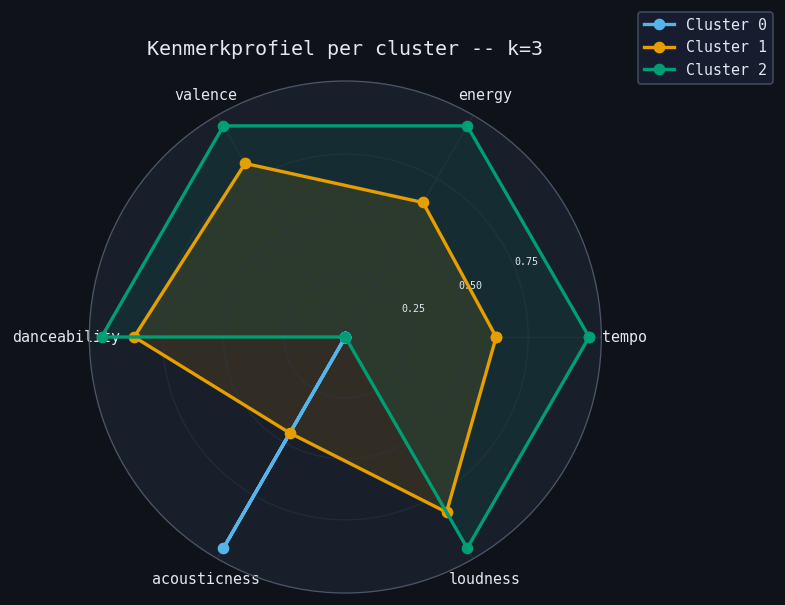

In [52]:
radar_features = [f for f in FEATURES if f in df.columns]
radar_data = df.groupby('cluster_k3')[radar_features].mean()

# Normaliseer per kenmerk naar [0, 1] voor vergelijkbaarheid
for col in radar_data.columns:
    col_min, col_max = radar_data[col].min(), radar_data[col].max()
    if col_max > col_min:
        radar_data[col] = (radar_data[col] - col_min) / (col_max - col_min)

n_feat  = len(radar_features)
angles  = np.linspace(0, 2 * np.pi, n_feat, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'projection': 'polar'})
ax.set_facecolor('#181e2a')

for idx, (cluster_id, row) in enumerate(radar_data.iterrows()):
    values = row.tolist() + row.tolist()[:1]
    color  = OKABE_ITO[idx % len(OKABE_ITO)]
    ax.plot(angles, values, 'o-', color=color, linewidth=2,
            label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_features, fontsize=9)
ax.set_yticks([0.25, 0.5, 0.75])
ax.set_yticklabels(['0.25', '0.50', '0.75'], fontsize=6, color='#4a5568')
ax.tick_params(colors='#e2e8f0')
ax.set_title('Kenmerkprofiel per cluster -- k=3', pad=16)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
ax.grid(color='#2d3748', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Vergelijkingstabel -- k=3 vs optimaal

### BIC vs. Silhouette: twee conflicterende signalen

| Criterium | k=3 | k=5 | Winnaar | Wat het betekent |
|---|---|---|---|---|
| **BIC** | 75271 | 71738 | k=5 | Betere log-likelihood fit |
| **Silhouette** | 0.134 | 0.072 | k=3 | Beter gescheiden clusters |

**BIC zegt k=5 is beter** — het model met 5 clusters verklaart de data statistisch beter.
**Silhouette bij k=5 is 0.072** — de clusters overlappen deels, maar zijn nog marginaal
onderscheidbaar (boven de drempel van 0.05).

**Interpretatie:** De audio-featureruimte heeft geen scherpe grenzen. BIC vindt meer
Gaussische componenten die de densiteit beschrijven, maar die componenten overlappen
sterk en zijn bij k > 5 niet meer muzikaal interpreteerbaar.

**Praktische conclusie voor RQ5:**
- k=3 is de **aanbevolen keuze voor playlistgeneratie** (interpreteerbaar, beter gescheiden)
- k=5 bevestigt dat de featureruimte een **continu spectrum** is — de drie-categorie indeling
  is een nuttige approximatie, niet een natuurlijke indeling van de data
- Toekomstig werk: een zachte, probabilistische toewijzing (GMM-kansen) gebruiken in
  plaats van harde drempelwaarden

In [53]:
comparison = pd.DataFrame([
    {
        'Model':        'k=3 (geforceerd)',
        'k':            3,
        'BIC':          round(config['k3_bic']),
        'Silhouette':   round(config['k3_silhouette'], 3),
        'BIC-verschil': 0,
    },
    {
        'Model':        f'k={optimal_k} (optimaal)',
        'k':            optimal_k,
        'BIC':          round(config['opt_bic']),
        'Silhouette':   round(config['opt_silhouette'], 3),
        'BIC-verschil': round(config['opt_bic'] - config['k3_bic']),
    },
])
display(comparison.set_index('Model'))

print('\nClustergroottes k=3:')
display(df['cluster_k3'].value_counts().sort_index().rename('n_songs'))

print(f'\nClustergroottes k={optimal_k}:')
display(df['cluster_opt'].value_counts().sort_index().rename('n_songs'))

bic_diff = config['opt_bic'] - config['k3_bic']
if bic_diff < -10:
    print(f'\n-> BIC-verschil = {bic_diff:.0f}: k={optimal_k} past duidelijk beter bij de data dan k=3.')
elif bic_diff > 10:
    print(f'\n-> BIC-verschil = {bic_diff:.0f}: k=3 past verrassend goed -- data ondersteunt drie groepen.')
else:
    print(f'\n-> BIC-verschil = {bic_diff:.0f}: k=3 en k={optimal_k} zijn vergelijkbaar.')

,k,BIC,Silhouette,BIC-verschil
Model,,,,
k=3 (geforceerd),3,75271,0.134,0
k=5 (optimaal),5,71738,0.072,-3533



Clustergroottes k=3:


cluster_k3
0     804
1    3688
2    2268
Name: n_songs, dtype: int64


Clustergroottes k=5:


cluster_opt
0     840
1    1888
2     646
3    1472
4    1914
Name: n_songs, dtype: int64


-> BIC-verschil = -3533: k=5 past duidelijk beter bij de data dan k=3.


---

## 10. BIC-stabiliteitssweep

BIC-modelselectie kan afhangen van de initialisatie van het GMM.
Deze sweep herhaalt de modelselectie met 5 verschillende random seeds
om te controleren of k=5 stabiel is of toevallig.

BIC-stabiliteitssweep (5 seeds)...
  seed=  0: optimaal k=5  (BIC-min=10, sil<0.05 vanaf k=6)
  seed= 42: optimaal k=5  (BIC-min=10, sil<0.05 vanaf k=6)
  seed=123: optimaal k=5  (BIC-min=10, sil<0.05 vanaf k=6)
  seed=456: optimaal k=5  (BIC-min=10, sil<0.05 vanaf k=6)
  seed=789: optimaal k=5  (BIC-min=10, sil<0.05 vanaf k=6)

Optimale k over 5 seeds: [5, 5, 5, 5, 5]
Mode: k=5, bereik: k=[5, 5]
Stabiel: optimale k is consistent k=5 ± 1.


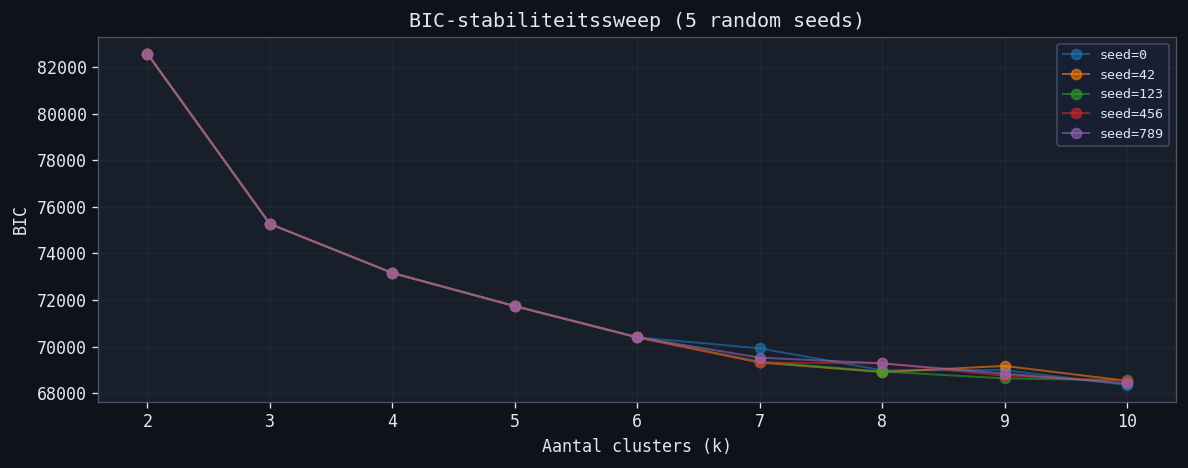

In [54]:
seeds = [0, 42, 123, 456, 789]
stability_results = {}

print("BIC-stabiliteitssweep (5 seeds)...")
for seed in seeds:
    bics_seed = {}
    sils_seed = {}
    for k in range(K_MIN, K_MAX + 1):
        gmm = GaussianMixture(
            n_components=k, covariance_type='full',
            n_init=3, random_state=seed,
        )
        gmm.fit(X)
        labels = gmm.predict(X)
        bics_seed[k] = gmm.bic(X)
        sils_seed[k] = silhouette_score(X, labels) if k > 1 else 0.0

    # Zelfde twee-criteria aanpak als modelselectie:
    # laatste k met silhouette ≥ 0.05 (betekenisvolle clusterstructuur)
    SILHOUETTE_THRESHOLD = 0.05
    silhouette_cutoff_s = None
    for k in sorted(bics_seed):
        if k >= 3 and sils_seed[k] < SILHOUETTE_THRESHOLD:
            silhouette_cutoff_s = k
            break
    optimal_k_bic_s = min(bics_seed, key=bics_seed.get)
    opt_k_seed = (silhouette_cutoff_s - 1) if silhouette_cutoff_s else optimal_k_bic_s

    stability_results[seed] = {'optimal_k': opt_k_seed, 'bics': bics_seed, 'sils': sils_seed}
    print(f"  seed={seed:3d}: optimaal k={opt_k_seed}  "
          f"(BIC-min={optimal_k_bic_s}, sil<{SILHOUETTE_THRESHOLD} vanaf k={silhouette_cutoff_s})")

opt_ks = [stability_results[s]['optimal_k'] for s in seeds]
print(f"\nOptimale k over 5 seeds: {opt_ks}")
print(f"Mode: k={max(set(opt_ks), key=opt_ks.count)}, bereik: k=[{min(opt_ks)}, {max(opt_ks)}]")

if max(opt_ks) - min(opt_ks) > 2:
    print("Waarschuwing: k varieert sterk over seeds -- optimale k is instabiel. Rapporteer als bereik.")
else:
    print(f"Stabiel: optimale k is consistent k={max(set(opt_ks), key=opt_ks.count)} ± 1.")

# Visualiseer BIC-curves per seed
fig, ax = plt.subplots(figsize=(10, 4))
for seed, data_s in stability_results.items():
    ks_s = sorted(data_s['bics'].keys())
    bics_s = [data_s['bics'][k] for k in ks_s]
    ax.plot(ks_s, bics_s, 'o-', alpha=0.6, linewidth=1.2, label=f'seed={seed}')

ax.set_xlabel('Aantal clusters (k)')
ax.set_ylabel('BIC')
ax.set_title('BIC-stabiliteitssweep (5 random seeds)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---

## 11. Clusterprofiel met semantische labels

Wat stelt elk cluster muzikaal voor? Gebruik de arousal-score formule uit Notebook 3
om een label te geven aan elk cluster:
- Arousal < 0.35 → **CALM-achtig**
- 0.35 ≤ Arousal ≤ 0.65 → **NEUTRAAL-achtig**
- Arousal > 0.65 → **ENERGY-achtig**

Dit verbindt het GMM-model terug naar de RQ5-vraag: herstelt de data-gedreven clustering
de handmatig ingestelde driedeling?

In [55]:
AROUSAL_WEIGHTS_NORM = {
    'energy':       0.35,
    'tempo':        0.30,
    'loudness':     0.20,
    'acousticness': -0.10,
    'danceability': 0.05,
}

def cluster_arousal_label(arousal: float) -> str:
    if arousal < 0.35:
        return 'CALM-achtig'
    elif arousal > 0.65:
        return 'ENERGY-achtig'
    return 'NEUTRAAL-achtig'


def cluster_profile_table(df: pd.DataFrame, cluster_col: str, k: int) -> pd.DataFrame:
    """Bouw een leesbare profieltabel met semantische labels gesorteerd op arousal."""
    rows = []
    for c in range(k):
        mask = df[cluster_col] == c
        sub  = df[mask][FEATURES]
        # Normaliseer naar [0,1] voor arousal-score (globaal over alle nummers)
        sub_norm = (sub - df[FEATURES].min()) / (df[FEATURES].max() - df[FEATURES].min() + 1e-9)
        arousal = sum(
            w * sub_norm[f] for f, w in AROUSAL_WEIGHTS_NORM.items() if f in sub_norm.columns
        ).mean()
        rows.append({
            'Cluster':        c,
            'N nummers':      int(mask.sum()),
            'Arousal score':  round(float(arousal), 3),
            'Label':          cluster_arousal_label(float(arousal)),
            'Tempo (gem)':    round(sub['tempo'].mean(), 1),
            'Energy (gem)':   round(sub['energy'].mean(), 3),
            'Valence (gem)':  round(sub['valence'].mean(), 3),
            'Acoust. (gem)':  round(sub['acousticness'].mean(), 3),
        })
    return pd.DataFrame(rows).sort_values('Arousal score').reset_index(drop=True)


print("=== Clusterprofiel k=3 (gesorteerd op arousal) ===")
display(cluster_profile_table(df, 'cluster_k3', 3))

print(f"\n=== Clusterprofiel k={optimal_k} (gesorteerd op arousal) ===")
display(cluster_profile_table(df, 'cluster_opt', optimal_k))

=== Clusterprofiel k=3 (gesorteerd op arousal) ===


,Cluster,N nummers,Arousal score,Label,Tempo (gem),Energy (gem),Valence (gem),Acoust. (gem)
0,0,804,0.119,CALM-achtig,102.7,0.048,0.196,0.984
1,1,3688,0.447,NEUTRAAL-achtig,117.2,0.522,0.466,0.458
2,2,2268,0.618,NEUTRAAL-achtig,126.2,0.793,0.525,0.018



=== Clusterprofiel k=5 (gesorteerd op arousal) ===


,Cluster,N nummers,Arousal score,Label,Tempo (gem),Energy (gem),Valence (gem),Acoust. (gem)
0,2,646,0.108,CALM-achtig,102.3,0.035,0.207,0.990
1,0,840,0.292,CALM-achtig,120.5,0.242,0.226,0.750
2,4,1914,0.437,NEUTRAAL-achtig,113.8,0.529,0.484,0.557
3,1,1888,0.562,NEUTRAAL-achtig,120.5,0.691,0.565,0.093
4,3,1472,0.636,NEUTRAAL-achtig,128.1,0.829,0.509,0.006


### Kruistabulatie -- GMM (k=3) vs. Notebook 3 classifier

Als de GMM-clusters overeenkomen met de handmatige driedeling, moeten de GMM-CALM-clusters
voornamelijk nummers bevatten die ook door Notebook 3 als `calm` zijn gelabeld.

Dit is de kern van RQ5: herstelt data-gedreven clustering de handmatig gekozen categorieën?

In [56]:
classified_frames = []
for codename in df['participant'].unique() if 'participant' in df.columns else []:
    classified_path = PROJECT_ROOT / 'data' / 'analysis' / codename / 'classified_songs.csv'
    if classified_path.exists():
        cl = pd.read_csv(classified_path)
        cl['participant'] = codename
        classified_frames.append(cl)

if classified_frames and 'uri' in df.columns:
    nb3_df = pd.concat(classified_frames, ignore_index=True)
    nb3_df = nb3_df.rename(columns={'class': 'nb3_class'})
    # Deduplicate URIs: same song may appear in multiple participants' libraries
    nb3_df = nb3_df.drop_duplicates(subset='uri', keep='first')

    merged = df[['uri', 'cluster_k3']].merge(
        nb3_df[['uri', 'nb3_class']], on='uri', how='inner'
    )

    if not merged.empty:
        ct = pd.crosstab(
            merged['cluster_k3'], merged['nb3_class'],
            rownames=['GMM cluster (k=3)'], colnames=['Notebook 3 klasse'],
        )
        ct.index = [f"Cluster {i}" for i in ct.index]
        print("Kruistabulatie GMM k=3 vs. Notebook 3 classifier:")
        display(ct)
        print(f"\nN nummers gematcht: {len(merged)} van {len(df)}")
        print("\nRij-percentages (per GMM-cluster):")
        display((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

        print("\nDominante Notebook 3 klasse per GMM-cluster:")
        for idx, row in ct.iterrows():
            dominant = row.idxmax()
            pct = row[dominant] / row.sum() * 100
            print(f"  {idx}: {dominant.upper()} ({pct:.0f}%)")
    else:
        print("Geen overeenkomende URIs gevonden tussen GMM en Notebook 3.")
else:
    print("Classified_songs.csv niet gevonden -- voer Notebook 3 eerst uit (REUSE_MODEL=False).")

Kruistabulatie GMM k=3 vs. Notebook 3 classifier:


Notebook 3 klasse,calm,energy,other
Cluster 0,201,0,603
Cluster 1,426,149,3113
Cluster 2,0,734,1534



N nummers gematcht: 6760 van 6760

Rij-percentages (per GMM-cluster):


Notebook 3 klasse,calm,energy,other
Cluster 0,25.0,0.0,75.0
Cluster 1,11.6,4.0,84.4
Cluster 2,0.0,32.4,67.6



Dominante Notebook 3 klasse per GMM-cluster:
  Cluster 0: OTHER (75%)
  Cluster 1: OTHER (84%)
  Cluster 2: OTHER (68%)
